# PPE Detection — Dataset Preparation for Roboflow

## Overview
Prepare a small YOLO object detection dataset for four classes: **Hardhat, NO-Hardhat, Safety Vest, and NO-Safety Vest**.

**Workflow:** load data → check labels and class balance → select 5,000 images → remove duplicate images and merge their labels → check final data → review sample boxes → export for Roboflow.

| Step | Purpose |
|---|---|
| 1 | Set up paths and load the original dataset |
| 2 | Check image–label pairs and YOLO annotations |
| 3 | Inspect original class balance and select the four classes |
| 4 | Build the 5,000-image subset |
| 5 | Keep one copy of each image and combine its annotations |
| 6 | Check the final dataset and its class balance |
| 7 | Visually review a few final annotations |
| 8 | Download the ZIP for Roboflow |





## Step 1 — Setup and dataset paths
Install the small dependencies, then load the original Kaggle dataset. If its folder is already present, reuse it. All paths and class settings are defined once here.

In [ ]:
%pip install -q kagglehub pyyaml pandas matplotlib pillow

In [ ]:
from pathlib import Path
from collections import Counter, defaultdict
from hashlib import sha256
import random, shutil
import kagglehub
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

ROOT = Path("/root/.cache/kagglehub/datasets/shlokraval/ppe-dataset-yolov8/versions/1")
if not ROOT.exists():
    ROOT = Path(kagglehub.dataset_download("shlokraval/ppe-dataset-yolov8/versions/1"))

V1 = Path("/content/ppe_curated_4class_v1")
FINAL = Path("/content/ppe_curated_4class_v3_merged_review")
SPLITS = ("train", "valid", "test")
EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
MAPPING = {3: 0, 8: 1, 13: 2, 10: 3}
NAMES = ["Hardhat", "NO-Hardhat", "Safety Vest", "NO-Safety Vest"]
QUOTAS = {"train": 3500, "valid": 1000, "test": 500}
raw_names = yaml.safe_load((ROOT / "data.yaml").read_text())["names"]
ORIGINAL_NAMES = (raw_names if isinstance(raw_names, list) else
                  [raw_names.get(i, raw_names.get(str(i))) for i in range(len(raw_names))])
print("Original dataset:", ROOT)
print("Final dataset:", FINAL)

100%|██████████| 2.35G/2.35G [00:33<00:00, 74.6MB/s]

Extracting files...


Original dataset: /root/.cache/kagglehub/datasets/shlokraval/ppe-dataset-yolov8/versions/1
Final dataset: /content/ppe_curated_4class_v3_merged_review


## Step 2 — Main quality check
Check that images have label files, labels have images, and each YOLO row has a valid class and normalized coordinates. Empty label files can represent background images; they are reported separately.

The same short checking function is reused for the original and final datasets. It also counts bounding boxes and images containing each class. This checks label structure, not whether a box is visually correct.

In [ ]:
def image_index(root, split):
    return {p.stem: p for p in (root / split / "images").rglob("*")
            if p.suffix.lower() in EXTENSIONS}

def read_labels(path):
    return [tuple(map(float, line.split())) for line in path.read_text().splitlines()
            if line.strip()]

def inspect_dataset(root, names):
    summary, distribution = [], []
    for split in SPLITS:
        images = image_index(root, split)
        labels = {p.stem: p for p in (root / split / "labels").glob("*.txt")}
        boxes, containing = Counter(), Counter()
        empty = invalid = 0
        for path in labels.values():
            try:
                rows = read_labels(path)
            except ValueError:
                invalid += 1
                continue
            empty += not rows
            present = set()
            for row in rows:
                valid = (len(row) == 5 and row[0].is_integer()
                         and 0 <= row[0] < len(names)
                         and all(0 <= v <= 1 for v in row[1:3])
                         and all(0 < v <= 1 for v in row[3:5]))
                if not valid:
                    invalid += 1
                    continue
                cls = int(row[0]); boxes[cls] += 1; present.add(cls)
            containing.update(present)
        summary.append(dict(split=split, images=len(images), label_files=len(labels),
                            missing_labels=len(images.keys() - labels.keys()),
                            orphan_labels=len(labels.keys() - images.keys()),
                            empty_labels=empty, invalid_annotations=invalid))
        distribution.extend(dict(split=split, **{"class": name},
                                 images=containing[i], bounding_boxes=boxes[i])
                            for i, name in enumerate(names))
    return pd.DataFrame(summary), pd.DataFrame(distribution)

original_summary, original_distribution = inspect_dataset(ROOT, ORIGINAL_NAMES)
display(original_summary)
assert original_summary[["missing_labels", "orphan_labels", "invalid_annotations"]].to_numpy().sum() == 0

,split,images,label_files,missing_labels,orphan_labels,empty_labels,invalid_annotations
0,train,30765,30765,0,0,848,0
1,valid,8814,8814,0,0,210,0
2,test,4423,4423,0,0,132,0


## Step 3 — Class balance and task scope
The chart shows the original distribution for the relevant PPE classes and `Person`. A bounding box is one labelled object; an image can contain several objects and classes.

We keep four PPE classes and exclude `Person` because its labels appeared incomplete in the original inspection. `NO-Hardhat` and `NO-Safety Vest` are positively labelled violations, not missing labels. Fewer examples of a class can make it harder to learn; the subset prioritizes the rarer vest violations.

| Original ID | New ID | Class |
|---:|---:|---|
| 3 | 0 | Hardhat |
| 8 | 1 | NO-Hardhat |
| 13 | 2 | Safety Vest |
| 10 | 3 | NO-Safety Vest |

The saved chart below is from the original notebook; rerunning updates it from the loaded data.

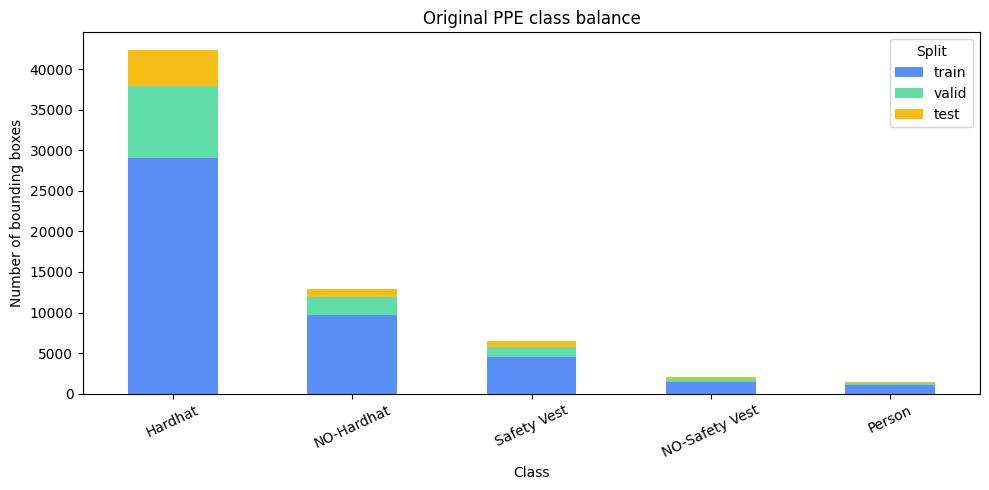

In [ ]:
def plot_balance(distribution, title, selected_names):
    table = distribution.pivot(index="class", columns="split", values="bounding_boxes")
    table = table.reindex(selected_names)[list(SPLITS)]
    table.plot.bar(stacked=True, figsize=(10, 5), color=["#5B8FF9", "#61DDAA", "#F6BD16"])
    plt.title(title); plt.xlabel("Class"); plt.ylabel("Number of bounding boxes")
    plt.xticks(rotation=25); plt.legend(title="Split"); plt.tight_layout(); plt.show()

plot_balance(original_distribution, "Original PPE class balance", NAMES + ["Person"])

## Step 4 — Select and copy 5,000 images
Keep the original splits, retain images containing vest violations first, then fill each quota by prioritizing rarer classes. Filter out other classes and remap the four class IDs. The image pixels are unchanged.

This retains the original selection method: 3,500 train, 1,000 validation, 500 test before deduplication. If v1 already exists, reuse it. On a fresh rebuild, a fixed seed controls tie breaking, but differences in source file traversal can change the chosen images.

In [ ]:
selected = {}
rng = random.Random(42)
if not V1.exists():
    for split in SPLITS:
        images, records = image_index(ROOT, split), []
        for path in (ROOT / split / "labels").rglob("*.txt"):
            rows = [(MAPPING[int(r[0])], *r[1:]) for r in read_labels(path)
                    if int(r[0]) in MAPPING]
            if rows and path.stem in images:
                records.append(dict(image=images[path.stem], rows=rows,
                                    classes={r[0] for r in rows}))
        availability = Counter(c for r in records for c in r["classes"])
        mandatory = [r for r in records if 3 in r["classes"]]
        remaining = [r for r in records if 3 not in r["classes"]]
        rng.shuffle(remaining)
        remaining.sort(key=lambda r: (sum(1 / availability[c] for c in r["classes"]),
                                      len(r["classes"])), reverse=True)
        assert len(mandatory) <= QUOTAS[split], "Quota smaller than mandatory images"
        selected[split] = mandatory + remaining[:QUOTAS[split] - len(mandatory)]
        assert len(selected[split]) == QUOTAS[split], "Not enough candidate images"
else:
    print("Reusing existing v1:", V1)

In [ ]:
def save_labels(path, rows):
    path.write_text("\n".join(f"{int(r[0])} " + " ".join(map(str, r[1:]))
                              for r in rows) + "\n")

def save_yaml(root):
    config = dict(path=str(root), train="train/images", val="valid/images",
                  test="test/images", nc=4, names=dict(enumerate(NAMES)))
    (root / "data.yaml").write_text(yaml.safe_dump(config, sort_keys=False))

if selected:
    for split, records in selected.items():
        for folder in ("images", "labels"):
            (V1 / split / folder).mkdir(parents=True, exist_ok=False)
        for record in records:
            image = record["image"]
            shutil.copy2(image, V1 / split / "images" / image.name)
            save_labels(V1 / split / "labels" / f"{image.stem}.txt", record["rows"])
    save_yaml(V1)
    print("Created v1:", V1)

Created v1: /content/ppe_curated_4class_v1


## Step 5 — Remove duplicate images and merge their labels
Some identical images had separate annotations: one copy labelled helmets and another labelled vests. Keep one image and combine those labels so useful annotations are retained.



In [ ]:
def pixel_hash(path):
    with Image.open(path) as image:
        image = image.convert("RGB")
        return sha256(str(image.size).encode() + image.tobytes()).hexdigest()

if FINAL.exists():
    print("Reusing existing v3:", FINAL)
else:
    groups = defaultdict(list)
    priority = {"test": 0, "valid": 1, "train": 2}
    for split in SPLITS:
        for image in image_index(V1, split).values():
            label = V1 / split / "labels" / f"{image.stem}.txt"
            groups[pixel_hash(image)].append((split, image, read_labels(label)))
    for split in SPLITS:
        for folder in ("images", "labels"):
            (FINAL / split / folder).mkdir(parents=True, exist_ok=False)
    report_rows = []
    for fingerprint, records in groups.items():
        records.sort(key=lambda r: (priority[r[0]], -len(r[2]), r[1].name))
        split, image, _ = records[0]
        merged = sorted({row for _, _, rows in records for row in rows})
        shutil.copy2(image, FINAL / split / "images" / image.name)
        save_labels(FINAL / split / "labels" / f"{image.stem}.txt", merged)
        if len(records) > 1:
            report_rows.append(dict(fingerprint=fingerprint, kept_split=split,
                                    kept_image=image.name, copies=len(records),
                                    merged_boxes=len(merged)))
    save_yaml(FINAL)
    pd.DataFrame(report_rows).to_csv(FINAL / "merge_report.csv", index=False)
    print("Unique images:", len(groups), "| Duplicate groups merged:", len(report_rows))

Unique images: 4896 | Duplicate groups merged: 104


## Step 6 — Final checks and class balance
Check image–label pairing, annotation format, and that no exact duplicate images remain anywhere in the final dataset. Recalculate class counts **after** merging, then plot the final balance.


In [ ]:
final_summary, final_distribution = inspect_dataset(FINAL, NAMES)
display(final_summary)
display(final_distribution)
assert final_summary[["missing_labels", "orphan_labels", "invalid_annotations"]].to_numpy().sum() == 0
fingerprints = [pixel_hash(p) for split in SPLITS for p in image_index(FINAL, split).values()]
assert len(fingerprints) == len(set(fingerprints)), "Duplicate images remain"
print("Checks passed | Unique images:", len(fingerprints))

,split,images,label_files,missing_labels,orphan_labels,empty_labels,invalid_annotations
0,train,3403,3403,0,0,0,0
1,valid,993,993,0,0,0,0
2,test,500,500,0,0,0,0


,split,class,images,bounding_boxes
0,train,Hardhat,717,2345
1,train,NO-Hardhat,742,2077
2,train,Safety Vest,2128,4479
3,train,NO-Safety Vest,661,1360
4,valid,Hardhat,160,513
5,valid,NO-Hardhat,234,629
6,valid,Safety Vest,613,1302
7,valid,NO-Safety Vest,201,424
8,test,Hardhat,81,218
9,test,NO-Hardhat,127,355


Checks passed | Unique images: 4896


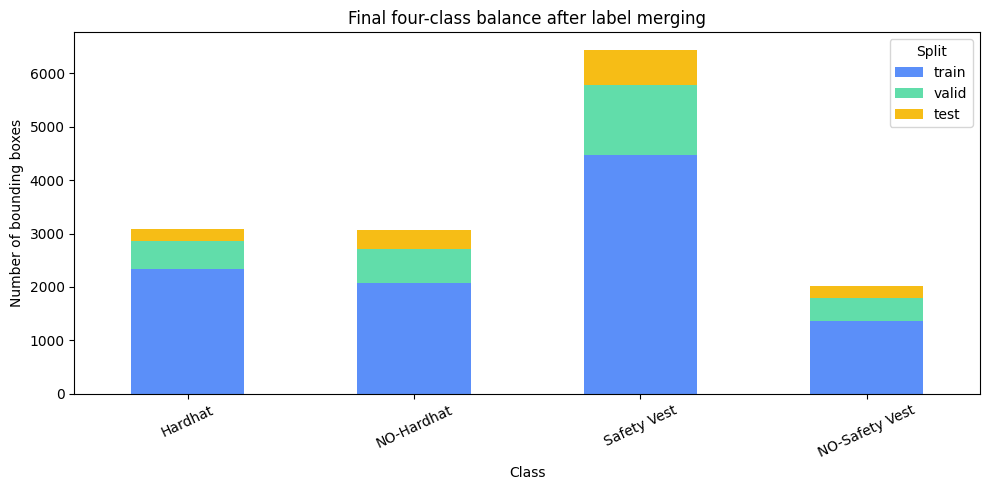

In [ ]:
plot_balance(final_distribution, "Final four-class balance after label merging", NAMES)

## Step 7 — Visual annotation check


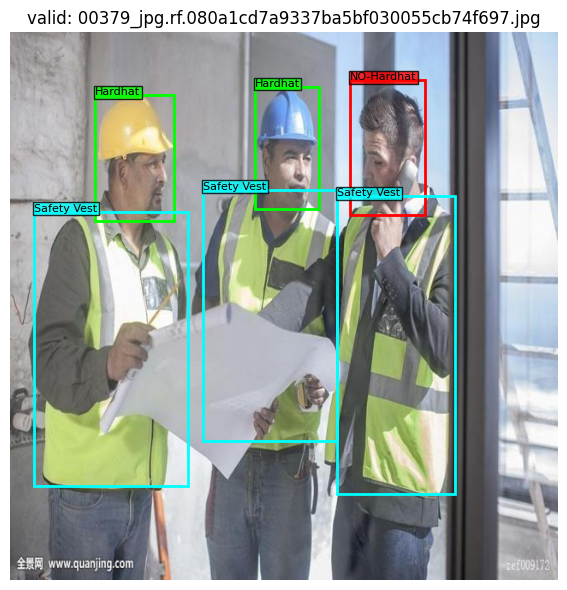

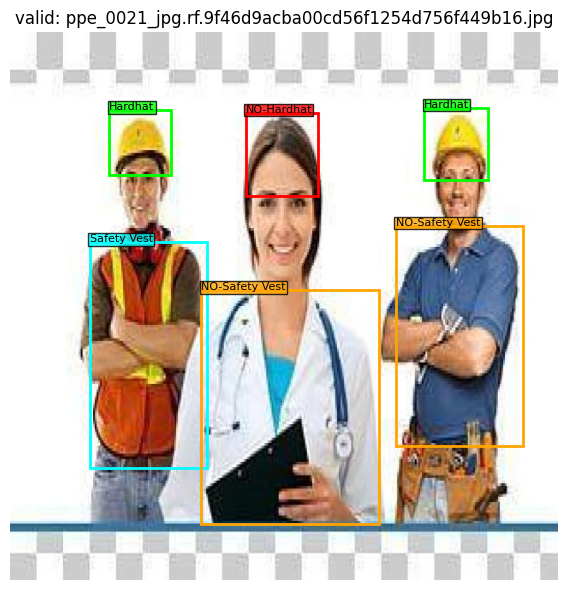

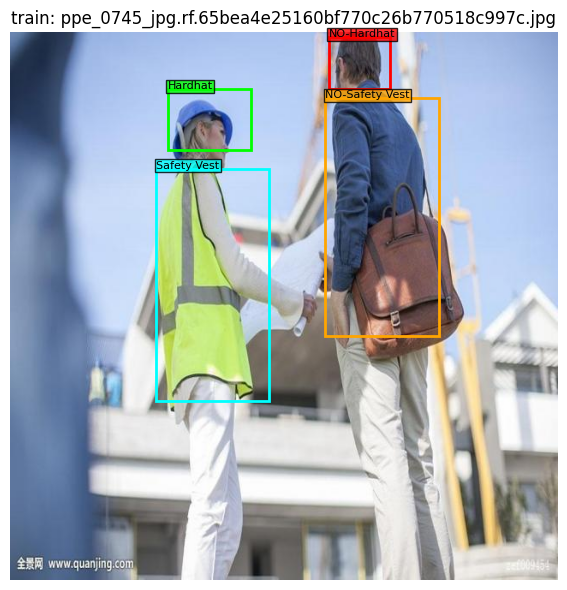

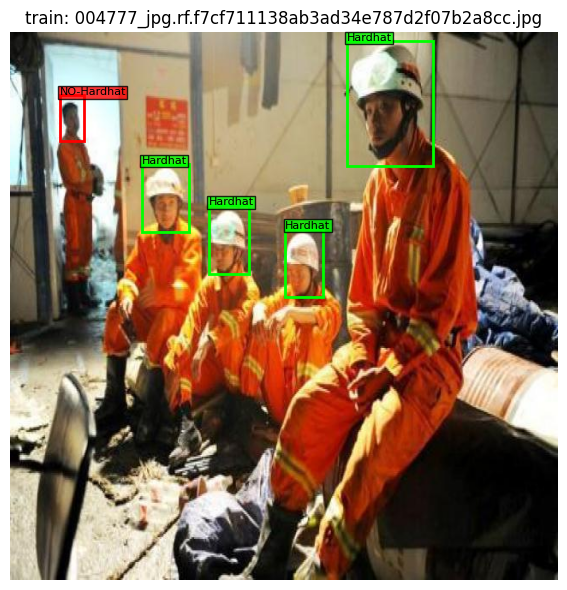

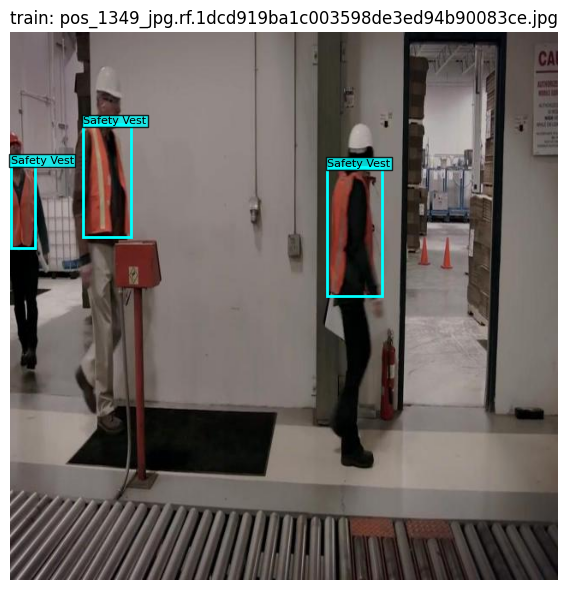

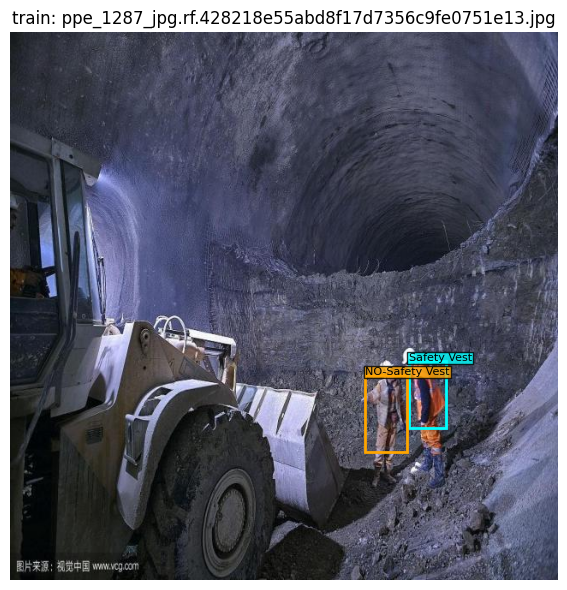

In [ ]:
COLORS = ["lime", "red", "cyan", "orange"]

def show_sample(split, image_name):
    path = FINAL / split / "images" / image_name
    with Image.open(path) as source:
        image = source.convert("RGB")
    width, height = image.size
    fig, ax = plt.subplots(figsize=(7, 6)); ax.imshow(image)
    for cls, xc, yc, bw, bh in read_labels(FINAL / split / "labels" / f"{path.stem}.txt"):
        cls = int(cls); x, y = (xc - bw/2)*width, (yc - bh/2)*height
        ax.add_patch(patches.Rectangle((x, y), bw*width, bh*height,
                                       fill=False, edgecolor=COLORS[cls], linewidth=2))
        ax.text(x, y, NAMES[cls], fontsize=8,
                bbox=dict(facecolor=COLORS[cls], alpha=0.8, pad=1))
    ax.set_title(f"{split}: {image_name}"); ax.axis("off")
    plt.tight_layout(); plt.show()

samples = []
report_path = FINAL / "merge_report.csv"
if not report_path.exists():
    report_path = FINAL / "duplicate_cleanup_report.csv"
if report_path.exists():
    review = pd.read_csv(report_path)
    if {"kept_split", "kept_image"} <= set(review.columns):
        samples = list(review[["kept_split", "kept_image"]].drop_duplicates()
                       .head(3).itertuples(index=False, name=None))
images = image_index(FINAL, "train")
for cls in range(4):
    match = next((p for p in (FINAL / "train" / "labels").glob("*.txt")
                  if any(r[0] == cls for r in read_labels(p))), None)
    if match:
        samples.append(("train", images[match.stem].name))
for split, name in dict.fromkeys(samples):
    show_sample(split, name)

## Step 8 — Export for Roboflow
Create a ZIP containing the final images, YOLO labels, and `data.yaml`, then download it. Import into an **Object Detection** project and preserve the existing train/validation/test assignments.

Review the imported annotations and confirm the four class names. Create a baseline dataset version without added augmentation; later augmentation experiments should affect training data only. This notebook stops at dataset export.

In [ ]:
from google.colab import files

zip_path = shutil.make_archive("/content/ppe_4class_v3", "zip", root_dir=FINAL)
print("Ready for Roboflow:", zip_path)
files.download(zip_path)

Ready for Roboflow: /content/ppe_4class_v3.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
import shutil

drive.mount("/content/drive")
shutil.copy2(
    "/content/ppe_4class_v3.zip",
    "/content/drive/MyDrive/ppe_4class_v3.zip"
)
print("تم النسخ إلى Drive")

Mounted at /content/drive
تم النسخ إلى Drive
